# Example Notebook for Fiber Library

This notebook is intended to provide some examples of usage for the Fiber library.

It makes use of ``py_pol`` to visualize some results, so I strongly recommend installing that, but it is not necessary to use the Fiber library. See also the notes on GitHub about modifications to ``py_pol`` to make this code work.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import optimize as opt
import plotly as pty
import time

from fibers import *

from py_pol.jones_vector import Jones_vector
from py_pol.jones_matrix import Jones_matrix
from py_pol.stokes import Stokes
from py_pol.utils import degrees

pi = np.pi
C_c = 299792458.0

## Single FiberLength Examples

### Basic Initialization and Exploration

Here is an example of a single long length of fiber.

In [3]:
# Initialize the fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
L0 = 1000         # Length of fiber
r0 = 4.1e-6       # Radius of core
r1 = 125e-6/2     # Radius of cladding
epsilon = 1.005   # Core noncircularity
m0 = 0.03652      # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

f = FiberLength(w0, T0, L0, r0, r1, epsilon, m0, m1, Tref, rc, tf, tr, mProps = {})

In [4]:
# Print properties of the fiber
print(f)

Fiber length, properties:
Length: 1000.0000 m
Operating wavelength: 1550.0000 nm
Operating temperature: 20.0000 °C
Reference temperature: 20.0000 °C
Base radius of the core: 4.1000 um
Radius of the cladding: 62.5000 um
Noncircularity a/b: 1.0050
Molar fraction of dopant in the core: 0.0365
Molar fraction of dopant in the cladding: 0.0000
Core index of refraction: 1.44982
Cladding index of refraction: 1.44462
Mode effective index of refraction: 1.44676
Effective group index: 1.46822
Normalized frequency V: 2.0391
Bend radius of curvature: N/A
Axial tension on bend: N/A
Twist rate: N/A
Differential group delay: 0.8309 ps
Polarization beat length: 12.5524 m
Chromatic dispersion coefficient D_CD: 13.7792 ps/(nm^2 km)


In [5]:
# Birefringences in rad/m
print(f.B_CNC)
print(f.B_ATS)
print(f.B_BND)
print(f.B_TWS)

0.14620594706324896
0.35434871396596923
0
0.0


In [6]:
# Set something different
f.epsilon = 1.001
print(f.B_CNC)
print(f.B_ATS)
print(f.B_BND)
print(f.B_TWS)

0.02941654846176605
0.0710114114444483
0
0.0


In [7]:
print("The chromatic dispersion of the fiber is {:.3f} ps/(nm^2 km).".format(f.calcD_CD()))
print("The polarization beat length of the fiber is {:.3f} m.".format(f.calcBeatLength()))
print("The DGD of the fiber is {:.3f} ps.".format(f.calcDGD()*1e12))

pd = f.calcPhaseDelay()*1e6
print("The average transit time through the fiber is {:.8f} us; the minimum and maximum time are {:.8f} us and {:.8f} us.".format(pd[0], pd[1], pd[2]))

The chromatic dispersion of the fiber is 13.779 ps/(nm^2 km).
The polarization beat length of the fiber is 62.564 m.
The DGD of the fiber is 0.167 ps.
The average transit time through the fiber is 4.82571305 us; the minimum and maximum time are 4.82571309 us and 4.82571301 us.


### Alternate Specs for Refractive Indices and Doping

Most of the properties used for initialization above will typically be known, with the exception of the doping concentrations in the core and cladding. More often datasheets will provide some properties of the indices of refraction of the core and cladding. To specify these, use the optional ``mProps`` dictionary argument. This dictionary requires four numbers. The keys 'w0' and 'T' are the wavelength and temperature at which the other two values are specified; additionally 'dn' is the refractive index difference between the core and cladding, a common find in optical fiber datasheets. The fourth value can be any of the following: 'm0' or 'm1', the doping concentration in the core or cladding (if you only know one of them), 'n0' or 'n1', the index of refraction of the core or cladding, or 'neff', the effective refractive index of the fundamental mode of the fiber. 

As an example, here is a fiber which is set to have no doping in the cladding and a 0.5% difference in refractive index between the core and cladding at 1550 nm and 23°C (the given ``m0`` and ``m1`` values are overriden by what's in thr ``mProps`` dictionary):

In [8]:
# Initialize the fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
L0 = 1000         # Length of fiber
r0 = 4.1e-6       # Radius of core
r1 = 125e-6/2     # Radius of cladding
epsilon = 1.005   # Core noncircularity
m0 = 0.03652      # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

f = FiberLength(w0, T0, L0, r0, r1, epsilon, m0, m1, Tref, rc, tf, tr, mProps = {'m1': 0, 'dn': 0.005, 'w0': 1550e-9, 'T': 23})

In [9]:
print("At T = {:.0f}°C, the current operating temperature, the fractional refractive index difference between core and cladding is {:.3f}%.".format(f.T0, (f.n0-f.n1)/f.n1*100))
f.T0 = 23
print("At the spec'd temperature of 23°C, the current operating temperature, the fractional refractive index difference between core and cladding is {:.3f}%.".format((f.n0-f.n1)/f.n1*100))

At T = 20°C, the current operating temperature, the fractional refractive index difference between core and cladding is 0.501%.
At the spec'd temperature of 23°C, the current operating temperature, the fractional refractive index difference between core and cladding is 0.500%.


In [10]:
f.m0

np.float64(0.050812563349756056)

### When Group Index $n_{g,\text{eff}}$ at Two Wavelengths is Spec'd

Many datasheets give an effective group index at two wavelengths. This section is an example module for finding the corresponding doping concentrations in the core and cladding. The example worked out here is Corning SMF-28e+ fiber, whose datasheet specs the effective group index at 1.4674 at 1310 nm and 1.4679 at 1550 nm, both at 23°C.

In [19]:
from scipy.interpolate import CubicSpline

Start by initializing a fiber with all other properties known except the ``m0`` and ``m1`` which can be anything for now.

In [20]:
# Initialize the fiber

w0 = 1310e-9      # Operating wavelength
T0 = 23           # Operating temperature
L0 = 1000         # Length of fiber
r0 = 4.1e-6       # Radius of core
r1 = 125e-6/2     # Radius of cladding
epsilon = 1.005   # Core noncircularity
m0 = 0.03         # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 23         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

f = FiberLength(w0, T0, L0, r0, r1, epsilon, m0, m1, Tref, rc, tf, tr, mProps = {})

The algorithm works as follows. For both wavelengths, we use ``f.calcNGEff()`` to find the effective group velocity on a grid of values of ``m0`` and ``m1``. For each ``m0``, varying ``m1`` will produce some value at which $n_{g,\text{eff}}$ equals the target for the corresponding wavelength. We store the value of ``m1`` (found by interpolation) that produces the target. We then have a set of data $m_1(m_0)$ for which $n_{g,\text{eff}}$ matches the target for each wavelength; these are the variables ``zeroLine1`` and ``zeroLine2`` (so called because the difference between the calculated and target refractive indices is zero). Let's find these "zero lines" first.

Use ``nGoal1`` and ``nGoal2`` to specify the target $n_{g,\text{eff}}$ values, and ``w1`` and ``w2`` to specify their reference wavelengths.

To change the ``m0, m1`` grids, change ``nx,ny`` (which are the number of points on the grid) or the bounds in the ``np.linspace`` arguments for ``m0s`` or ``m1s``.

In [21]:
w1 = 1310e-9
w2 = 1550e-9
nGoal1 = 1.4674
nGoal2 = 1.4679

nx = 101; ny = 101
m0s = np.linspace(0.02,0.04,nx)
m1s = np.linspace(-0.03,-0.01,ny)

ngeff1310 = np.zeros((nx,ny))
ngeff1550 = np.zeros((nx,ny))

f.w0 = w1
zeroLine1 = np.zeros(nx)
for i in range(nx):
    f.m0 = m0s[i]
    ngs = np.zeros(ny)
    for j in range(ny):
        f.m1 = m1s[j]
        ngs[j] = f.calcNGEff()
    interFunc = CubicSpline(m1s, ngs)
    zeroLine1[i] = opt.fsolve(lambda x: interFunc(x) - nGoal1, m1s[round(ny/2)])[0]

f.w0 = w2
zeroLine2 = np.zeros(nx)
for i in range(nx):
    f.m0 = m0s[i]
    ngs = np.zeros(ny)
    for j in range(ny):
        f.m1 = m1s[j]
        ngs[j] = f.calcNGEff()
    interFunc = CubicSpline(m1s, ngs)
    zeroLine2[i] = opt.fsolve(lambda x: interFunc(x) - nGoal2, m1s[round(ny/2)])[0]

Now we plot the "zero lines." There should be a single place of intersection: that is the value of ``m0, m1`` that gives the correct $n_{g,\text{eff}}$ for **both** wavelengths.

If the plot below has no intersection, try moving the ``m0s`` or ``m1s`` grid around using the ``np.linspace()`` bounds. Typically you can see visually where the curves look like they might intersect and that can tell you where to move the grid (for instance, if the curves look like they'll intersect to the right of the plot, move the ``m0`` bounds toward more positive values; if the lines loook like they intersect below the plot, move the ``m1`` bounds more negative; and so on). If it's still not possible to find an intersection, it's likely that the target refractive indices you have provided are not physically feasible within the model implemented by this library.

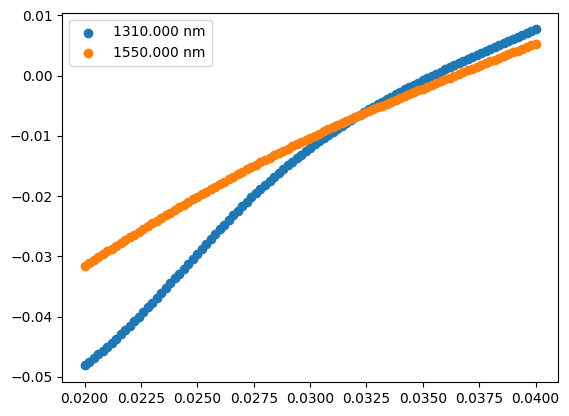

In [22]:
fig, ax = plt.subplots()
ax.scatter(m0s, zeroLine1, label='{:.3f} nm'.format(w1*1e9))
ax.scatter(m0s, zeroLine2, label='{:.3f} nm'.format(w2*1e9))
ax.legend()
plt.show()

Once the curves above have an intersection, use the x-coordinate of that intersection as the ``m0guess`` in the cell below. The cell interpolates the difference between the two curves above to find where the zero occurs, then prints out the final ``m0`` and ``m1`` values.

In [23]:
m0guess = 0.0325

zeroLineDiffFunc = CubicSpline(m0s, zeroLine2 - zeroLine1)
m0final = opt.fsolve(lambda x: zeroLineDiffFunc(x), m0guess)[0]
print("m0:", m0final)

zeroLine1Func = CubicSpline(m0s, zeroLine1)
m1final = zeroLine1Func(m0final)
print("m1:", m1final)

m0: 0.032006763575505956
m1: -0.006916799250532896


Let's give the above fiber these values and then check that the refractive indices are right.

In [24]:
f.m0 = m0final
f.m1 = m1final

f.w0 = w1
print("At {:.3f} nm, the effective group index is {:.5f}.".format(w1*1e9, f.calcNGEff()))
f.w0 = w2
print("At {:.3f} nm, the effective group index is {:.5f}.".format(w2*1e9, f.calcNGEff()))

At 1310.000 nm, the effective group index is 1.46740.
At 1550.000 nm, the effective group index is 1.46790.


This ``Fiber`` object was set up to model Corning SMF-28e+ fiber. That fiber generally has a zero in the group velocity dispersion $D_{CD}$ around 1313 nm and a spec'd zero-dispersion slope. We check below, finding $D_{CD}$ values that match the SMF-28e datasheet well.

The zero dispersion slope is 0.0770 ps/(nm^2 km) at about 1321.50 nm.
Fitted values are 0.0743 ps/(nm^2 km) at about 1322.98 nm.


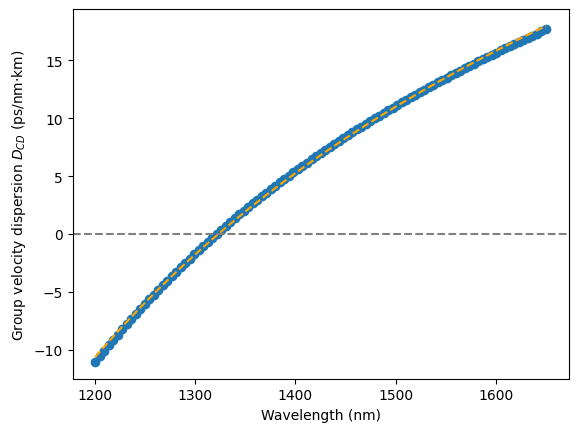

In [25]:
from scipy import optimize as opt

f.T0 = 23
f.Tref = 23

w0s = np.linspace(1200, 1650, 101)*1e-9
dcds = np.zeros(len(w0s))
for i in range(len(w0s)):
    f.w0 = w0s[i]
    dcds[i] = f.calcD_CD()

closestToZeroInd = np.argmin(np.abs(dcds))
zeroDispersionSlope = (dcds[closestToZeroInd] - dcds[closestToZeroInd - 1])/(w0s[closestToZeroInd] - w0s[closestToZeroInd - 1])/1e9
print("The zero dispersion slope is {:.4f} ps/(nm^2 km) at about {:.2f} nm.".format(zeroDispersionSlope, w0s[closestToZeroInd]*1e9))

def testFunc(w0, S0, lambda0): return (S0/4)*(w0 - lambda0**4/w0**3)
popt, pcov = opt.curve_fit(testFunc, w0s, dcds, p0 = np.array([0.073e9, 1350e-9]))
print("Fitted values are {:.4f} ps/(nm^2 km) at about {:.2f} nm.".format(popt[0]/1e9, popt[1]*1e9))

fig, ax = plt.subplots()
ax.scatter(w0s*1e9, dcds)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Group velocity dispersion $D_{CD}$ (ps/nm$ \\cdot $km)")
ax.plot(w0s*1e9, testFunc(w0s, popt[0], popt[1]), color='orange', linestyle='dashed')
ax.axhline(y = 0, color='gray', linestyle='dashed')
plt.show()

Note that the deviation of the fit from the data is expected: the fit function is a heuristic one, known to match real data only to a few percent.

It is important to note that the ability of this code to match the group refractive indices at two wavelengths does not mean it's correct at all wavelengths or that we have somehow reverse-engineered Corning SMF-28e+ fiber. The code uses germanium doping to increase refractive indices and fluorine doping to decrease them, and it also uses step-index optical fibers; all of these may be untrue for any commercial fiber. For example, both core and cladding of Corning fibers may have some fluorine doping **in addition to** germanium doping of the core, or there may be some chlorine doping. This code implements a model, not an attempt to reverse-engineer anyone's fibers. To make clear that this is not a particularly good model, the cutoff wavelength of Corning SMF-28e+ fiber is specified at 1260 nm, but this fiber's cutoff wavelength is very different:

In [29]:
print(str(f.v*f.w0/2.405*1e9), "nm")

1604.0034131477244 nm


### Chromatic Dispersion Example

In the following example, we demonstrate chromatic dispersion by looking at the output of a fiber heated from 20°C ot 25°C at two wavelengths, 1560 nm and 1650 nm, for the same input polarization state. 

In [2]:
# Initialize the fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
L0 = 100          # Length of fiber
r0 = 4.1e-6       # Radius of core
r1 = 125e-6/2     # Radius of cladding
epsilon = 1.005   # Core noncircularity
m0 = 0.0358       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

f = FiberLength(w0, T0, L0, r0, r1, epsilon, m0, m1, Tref, rc, tf, tr, mProps = {})

# Array of temperatures to sample
T0arr = np.linspace(20, 25, 11)

# To store Jones matrices at two wavelengths at different temperatures
J0arr = np.zeros((len(T0arr), 2, 2), dtype=np.complex128)
J1arr = np.zeros((len(T0arr), 2, 2), dtype=np.complex128)

for i in range(len(T0arr)):
    f.w0 = 1560e-9; f.T0 = T0arr[i]
    J0arr[i,:,:] = f.J0
    f.w0 = 1650e-9;
    J1arr[i,:,:] = f.J0

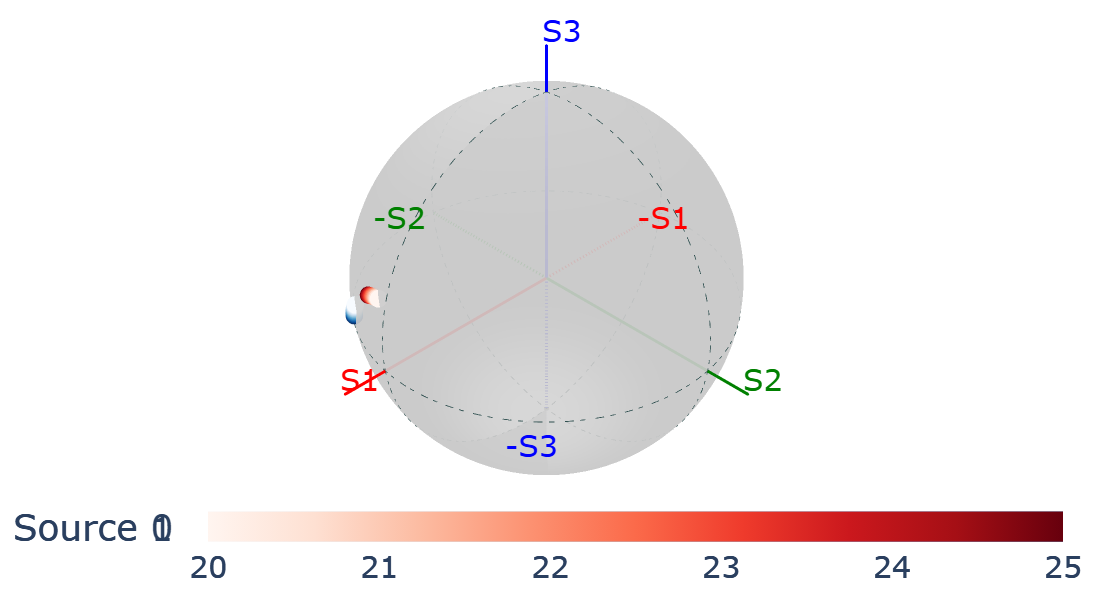

In [3]:
Ei = Jones_vector("Source 0"); Ei.linear_light(azimuth = 10*degrees, amplitude=1)
J0 = Jones_matrix("J0"); J0.from_matrix(J0arr)
J1 = Jones_matrix("J1"); J1.from_matrix(J1arr)
E0 = J0 * Ei; E1 = J1 * Ei
S0 = Stokes("Source 0"); S0.from_Jones(E0)
S1 = Stokes("Source 1"); S1.from_Jones(E1)

fig0 = pty.subplots.make_subplots(rows=1, cols=1, specs=[[{'type':'surface'}]])
S0.draw_poincare(fig=fig0, draw_axes=True, colormap='blues', param=T0arr, show_fig=False)
S1.draw_poincare(fig=fig0, draw_axes=True, colormap='reds', param=T0arr, show_fig=False)
fig0.show()

## Fiber Paddle Set Examples

In [4]:
# Initialize a set of paddles
# This approximately matches the specs of ThorLabs FPC563
w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
r0 = 4.1e-6       # Radius of core
r1 = 125e-6/2     # Radius of cladding
epsilon = 1.005   # Core noncircularity
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature

nPaddles = 3
rps = np.array([0.056/2, 0.056/2, 0.056/2])
angles = np.array([10, 50, 20])*pi/180
tfs = np.array([0, 0, 0])
Ns = np.array([2, 4, 2])
gapLs = np.array([0.02, 0.02, 0.02])

f = FiberPaddleSet(w0, T0, r0, r1, epsilon, m0, m1, Tref, nPaddles, rps, angles, tfs, Ns, gapLs)
f.J0

array([[ 0.07120526-0.90539392j, -0.0537916 +0.4150881j ],
       [ 0.0537916 +0.4150881j ,  0.07120526+0.90539392j]])

ThorLabs says in the manual for the FPC563 that at about 950 nm, four turns should act like a half-wave plate... we can check that by initializing a paddle set with a single paddle whose angle we vary:

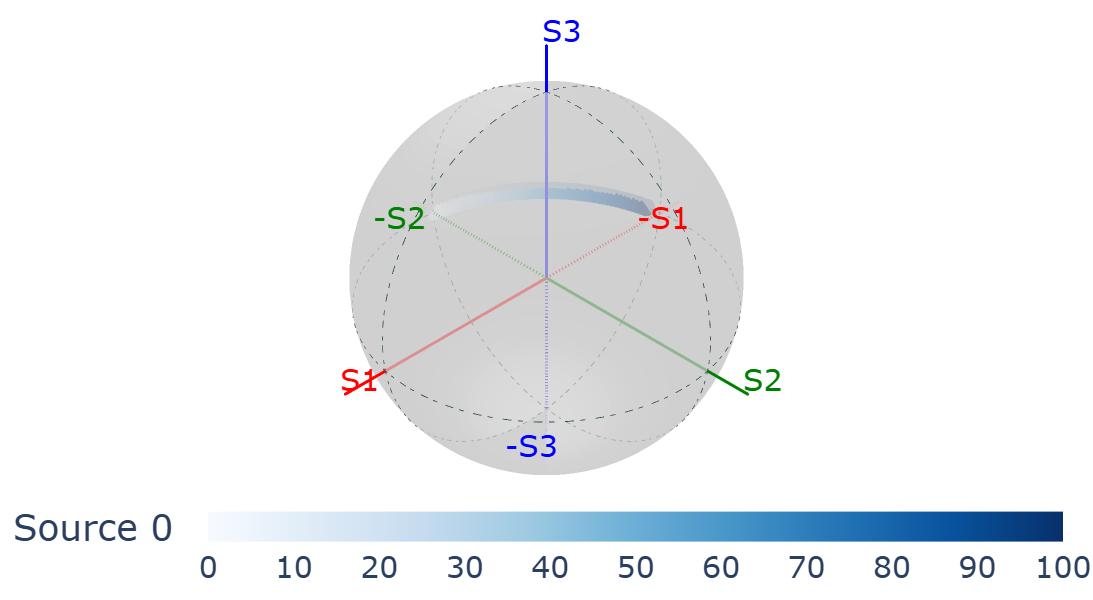

In [5]:
w0 = 950e-9
T0 = 20
r0 = 4.1e-6
r1 = 125e-6/2
epsilon = 1.000
m0 = 0.0347
m1 = 0.000
Tref = 20

nPaddles = 1
rps = np.array([0.056/2])
tfs = np.array([0])
Ns = np.array([4])
gapLs = np.array([0.02])

paddleAngles = np.linspace(1e-6,100,51)*pi/180

J0arr = np.zeros((len(paddleAngles), 2, 2), dtype=np.complex128)
f = FiberPaddleSet(w0, T0, r0, r1, epsilon, m0, m1, Tref, nPaddles, rps, np.array([paddleAngles[0]]), tfs, Ns, gapLs)

for i in range(len(paddleAngles)):
    f.angles[0] = paddleAngles[i]
    J0arr[i,:,:] = f.J0

Ei = Jones_vector("Source 0"); Ei.linear_light(azimuth = 45*degrees, amplitude=1)
J0 = Jones_matrix("J0"); J0.from_matrix(J0arr)
#J1 = Jones_matrix("J1"); J1.from_matrix(J1arr)
E0 = J0 * Ei; #E1 = J1 * Ei
S0 = Stokes("Source 0"); S0.from_Jones(E0)
#S1 = Stokes("Source 1"); S1.from_Jones(E1)

fig0 = pty.subplots.make_subplots(rows=1, cols=1, specs=[[{'type':'surface'}]])
S0.draw_poincare(fig=fig0, draw_axes=True, colormap='blues', param=paddleAngles*180/pi, show_fig=False)
#S1.draw_poincare(fig=fig0, draw_axes=True, colormap='reds', param=T0arr, show_fig=False)
fig0.show()

Here is an example of a paddle set with three paddles where we rotate the middle one and look at the output polarization:

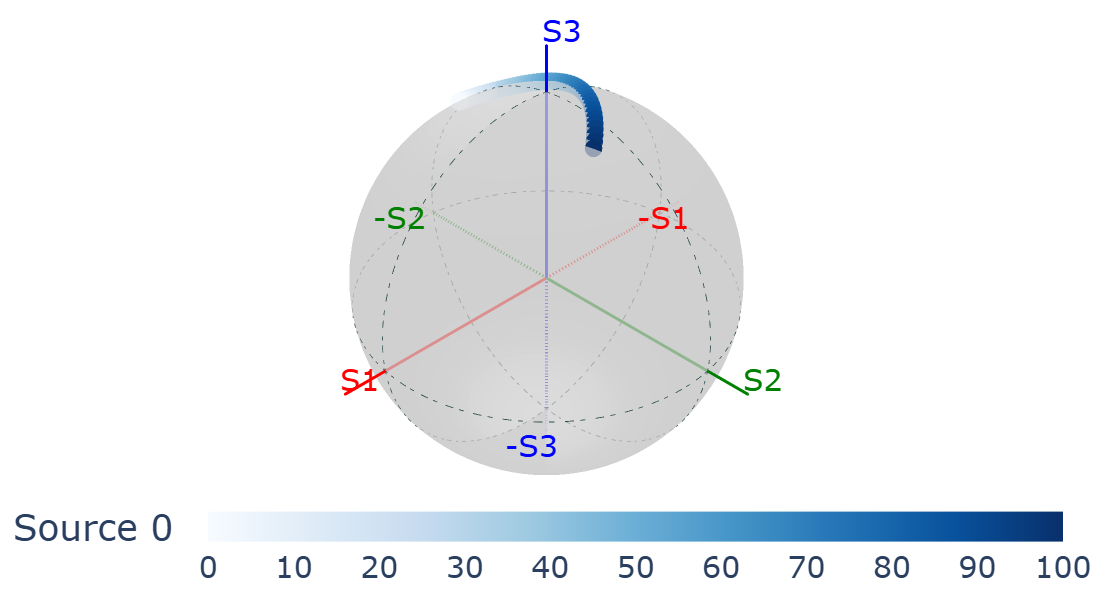

In [6]:
w0 = 1550e-9
T0 = 20
r0 = 4.1e-6
r1 = 125e-6/2
epsilon = 1.003
m0 = 0.0347
m1 = 0.000
Tref = 20

nPaddles = 3
rps = np.array([0.056/2, 0.056/2, 0.056/2])
tfs = np.array([0, 0, 0])
Ns = np.array([2, 4, 2])
gapLs = np.array([0.02, 0.02, 0.02])

paddleAngles = np.linspace(1e-6,100,51)*pi/180

J0arr = np.zeros((len(paddleAngles), 2, 2), dtype=np.complex128)
f = FiberPaddleSet(w0, T0, r0, r1, epsilon, m0, m1, Tref, nPaddles, rps, np.array([10, paddleAngles[0], 30]), tfs, Ns, gapLs)

for i in range(len(paddleAngles)):
    f.angles[1] = paddleAngles[i]
    J0arr[i,:,:] = f.J0

Ei = Jones_vector("Source 0"); Ei.linear_light(azimuth = 45*degrees, amplitude=1)
J0 = Jones_matrix("J0"); J0.from_matrix(J0arr)
#J1 = Jones_matrix("J1"); J1.from_matrix(J1arr)
E0 = J0 * Ei; #E1 = J1 * Ei
S0 = Stokes("Source 0"); S0.from_Jones(E0)
#S1 = Stokes("Source 1"); S1.from_Jones(E1)

fig0 = pty.subplots.make_subplots(rows=1, cols=1, specs=[[{'type':'surface'}]])
S0.draw_poincare(fig=fig0, draw_axes=True, colormap='blues', param=paddleAngles*180/pi)
#S1.draw_poincare(fig=fig0, draw_axes=True, colormap='reds', param=T0arr, show_fig=False)
fig0.show()

## Random Long Fibers

Here we demonstrate the Fiber class by using its ``random()`` method to make a random fiber.

This fiber has total length 26 km, split into 50 long birefringent segments which are specified to be randomly selected from a Gaussian whose standard deviation is 50 m (and whose mean is internally calculated to fit the total length requirement). The doping concentration for all the fibers is specified to be the same, as is the temperature. 

Because ``hingeType = 1``, this fiber has arbitrary rotators for hinges.

In [2]:
Ltot = 26e3       # Total length of fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

N0 = 50           # Number of hinges

segmentDict = {'epsilon': 1.005, 'm0': m0, 'm1': m1, 'T0': T0, 'Tref': Tref, 'rc': 0, 'tf': 0, 'tr': 0, 'L0': {'scale': 50, 'dist': 'normal'}}
hingeDict = {}

f = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 1, hingeStart = False, hingeEnd = False, arbRotStart = False)
print("The total DGD of the fiber is {:.3f} ps.".format(f.calcDGD()*1e12))
print("The total Jones matrix of the fiber is:")
print(f.J0)

The total DGD of the fiber is 2.705 ps.
The total Jones matrix of the fiber is:
[[-0.53281105-0.3385812j   0.29867895-0.71572762j]
 [-0.29867895-0.71572762j -0.53281105+0.3385812j ]]


This fiber has paddle sets for hinges instead, and we specify each paddle set to have 3 paddles with 2, 4, and 2 turns of fiber, respectively. The angles and radii of curvatures are randomly drawn based on default settings.

In [3]:
Ltot = 26e3       # Total length of fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

N0 = 50           # Number of hinges

segmentDict = {'m0': m0, 'm1': m1, 'T0': T0, 'Tref': Tref, 'rc': 0, 'tf': 0, 'tr': 0, 'L0': {'scale': 50, 'dist': 'normal'}}
hingeDict = {'nPaddles': 3, 'Ns': np.array([2, 4, 2]), 'T0': T0, 'Tref': Tref}

f = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 0, hingeStart = False, hingeEnd = False, arbRotStart = False)
print("The total DGD of the fiber is {:.3f} ps.".format(f.calcDGD()*1e12))
print("The total Jones matrix of the fiber is:")
print(f.J0)

The total DGD of the fiber is 1.973 ps.
The total Jones matrix of the fiber is:
[[-0.65373567-0.07938191j  0.35430319+0.66392578j]
 [-0.35430319+0.66392578j -0.65373567+0.07938191j]]


We can see a few properties of this fiber, including where the hinges are within ``f.fibers``:

In [4]:
print(f)

Optical fiber of total length 26000.0000 m, containing 99 separate fiber objects.
The hinges, which are sets of fiber paddles, are at the following indices of the object.fibers array.
[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 85 87 89 91 93 95
 97]


In [5]:
# The phase delays, with the same syntax as FiberLength.calcPhaseDelay() above:
pd = f.calcPhaseDelay()*1e9
print("The average transit time through the fiber is {:.5f} ns; the minimum and maximum time are {:.5f} ns and {:.5f} ns.".format(pd[0], pd[1], pd[2]))

The average transit time through the fiber is 125451.65941 ns; the minimum and maximum time are 125451.66023 ns and 125451.65860 ns.


In [6]:
# The number of FiberLengths and FiberPaddleSets
print(len(f.fibers))
# The asymmetric thermal stress birefringence of some segment in the fiber (rad/m)
print(f.fibers[28].B_ATS)

# To change something about one of the fibers, we need to change the segmentDict
print(f.J0)
print(f.fibers[28].epsilon)
f.segmentDict['epsilon'][14] = 1.007
print(f.fibers[28].epsilon)
print(f.J0)

99
0.20035437763700048
[[-0.65373567-0.07938191j  0.35430319+0.66392578j]
 [-0.35430319+0.66392578j -0.65373567+0.07938191j]]
1.0030959799538124
1.007
[[-0.92941573+0.29940087j -0.08253492+0.19933268j]
 [ 0.08253492+0.19933268j -0.92941573-0.29940087j]]


Gives a different Jones matrix.

An example calculation one might want to do is the average DGD given some ensemble of fibers. Here is such a calculation (takes about 30 seconds on my machine). After generating the fibers and storing their DGDs, we fit to an approximate Maxwellian and extract $E[\tau]$, the average DGD:

In [7]:
Ltot = 26e3       # Total length of fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

N0 = 20           # Number of hinges

segmentDict = {'m0': m0, 'm1': m1, 'T0': T0, 'Tref': Tref, 'rc': 0, 'tf': 0, 'tr': 0, 'L0': {'scale': 50, 'dist': 'normal'}}
hingeDict = {}

t0 = time.time()
nExp = 1000
dgds = np.zeros(nExp)
for i in range(nExp):
    f = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 1, hingeStart = False, hingeEnd = False, arbRotStart = False)
    dgds[i] = f.calcDGD()*1e12
print("Time taken: {:.2f} seconds".format(time.time() - t0))

Time taken: 14.45 seconds


E[t] = 3.422 ps
This corresponds to D_PMD = 0.671 ps/sqrt(km).
 


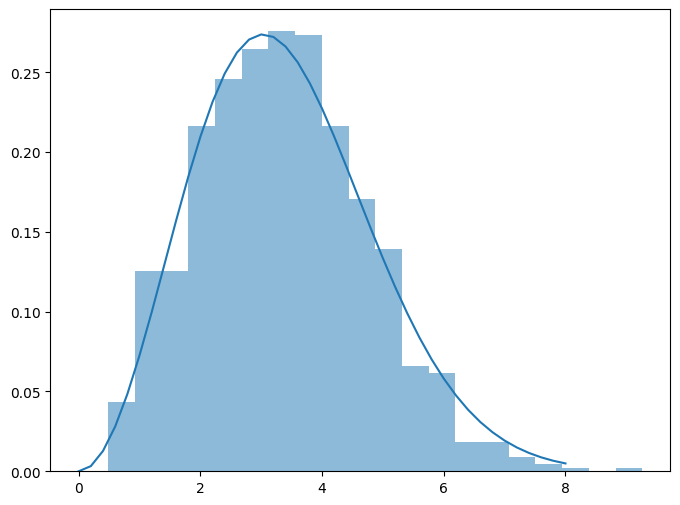

In [8]:
def MB(x, a): return (32/pi**2)*(x**2/a**3)*np.exp(-4*(x**2)/(pi*(a**2)))

ns, bins = np.histogram(dgds, bins=20)

x2 = np.linspace(0, 8, 41)
xs = (bins[1:] + bins[:-1])/2
ys = ns/np.sum(ns * (bins[1]-bins[0]))

popt, pcov = opt.curve_fit(MB, xs, ys, p0=np.array([10]))
print("E[t] = {:.3f} ps".format(popt[0]))
print("This corresponds to D_PMD = {:.3f} ps/sqrt(km).".format(popt[0]/np.sqrt(Ltot/1e3)))
print(" ")

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(xs, ys, width=(bins[1]-bins[0])*1.0, alpha=0.5)
ax.plot(x2, MB(x2, popt[0]))
plt.show()

In some cases (for example, low-PMD fibers formed by spinning the preform), you might want to insert arbitrary rotations into your segments while still having "hinges" that you can control. You can do this with the ``addRotators`` option on the initialization of the ``Fiber`` object or the ``Fiber.random()`` method. Here is an example comparing a 26-km fiber with 5 fiber paddle hinges and no rotators to the same scenario but with arbitrary rotators spaced on average 50 meters apart. The DGD is much lower because the of the rotators.

In [9]:
Ltot = 26e3       # Total length of fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

N0 = 20           # Number of hinges

segmentDict = {'m0': m0, 'm1': m1, 'T0': T0, 'Tref': Tref, 'rc': 0, 'tf': 0, 'tr': 0, 'L0': {'scale': 50, 'dist': 'normal'}}
hingeDict = {'nPaddles': 3, 'Ns': np.array([2, 4, 2])}

f1 = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 0, hingeStart = False, hingeEnd = False, arbRotStart = False)
print("The total DGD of the fiber is {:.3f} ps.".format(f1.calcDGD()*1e12))

f2 = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 0, hingeStart = False, hingeEnd = False, arbRotStart = False, addRotators = {'mean': 50, 'scale': 10, 'dist': 'normal'})
print("The total DGD of the fiber is {:.3f} ps.".format(f2.calcDGD()*1e12))

The total DGD of the fiber is 5.583 ps.
The total DGD of the fiber is 0.151 ps.


Note that, even though the rotators are "arbitrary", they are stable in the implementation, meaning you can still change any parameters without affecting the rotators (which are assumed to be independent of all parameters). Below, the very slight change to the Jones matrix arises from the small wavelength change; if the arbitrary rotators were randomly drawn every evaluation, the Jones matrix would be completely different.

In [10]:
Ltot = 26e3       # Total length of fiber

w0 = 1550e-9      # Operating wavelength
T0 = 20           # Operating temperature
m0 = 0.0347       # Doping concentration in core
m1 = 0.000        # Doping concentration in cladding
Tref = 20         # Reference temperature
rc = 0            # Bend radius of curvature
tf = 0            # Axial tension
tr = 0            # Twist rate

N0 = 20           # Number of hinges

segmentDict = {'m0': m0, 'm1': m1, 'T0': T0, 'Tref': Tref, 'rc': 0, 'tf': 0, 'tr': 0, 'L0': {'scale': 50, 'dist': 'normal'}}
hingeDict = {'nPaddles': 3, 'Ns': np.array([2, 4, 2])}

f2 = Fiber.random(w0, Ltot, N0, segmentDict, hingeDict, hingeType = 0, hingeStart = False, hingeEnd = False, arbRotStart = False, addRotators = {'mean': 50, 'scale': 10, 'dist': 'normal'})
print("The total DGD of the fiber is {:.5f} ps.".format(f2.calcDGD()*1e12))
print("The Jones matrix at {:.2f} nm is".format(f2.w0*1e9) + "\n" + str(f2.J0))
print(" ")

f2.w0 = 1550.01e-9
print("The total DGD of the fiber is {:.5f} ps.".format(f2.calcDGD()*1e12))
print("The Jones matrix at {:.2f} nm is".format(f2.w0*1e9) + "\n" + str(f2.J0))

The total DGD of the fiber is 0.30097 ps.
The Jones matrix at 1550.00 nm is
[[-0.67365687+0.11456025j  0.04600753+0.7286602j ]
 [-0.04600753+0.7286602j  -0.67365687-0.11456025j]]
 
The total DGD of the fiber is 0.30116 ps.
The Jones matrix at 1550.01 nm is
[[-0.6742836 +0.11368214j  0.04579541+0.72823127j]
 [-0.04579541+0.72823127j -0.6742836 -0.11368214j]]
